In [1]:
import scipy.linalg as linalg
import numpy as np
np.set_printoptions(precision=1)

## Normed Vector Spaces
In the previous section, we introduced vector spaces as algebraic structures that allow addition and scalar multiplication. We have also seen that vectors are geometric objects: their addition and scaling can be visualized by geometric properties. Another geometric property of a vector is the length, which is measured by a norm.
````{prf:definition}
A normed vector space is a vector space $\mathcal{V}$ with a
function $\lVert\cdot\rVert:\mathcal{V}\rightarrow \mathbb{R}_+$, called **norm**, satisfying the following properties for all $\vvec{v},\vvec{w}\in\mathcal{V}$ and $\alpha\in\mathbb{R}$:
\begin{align*}
    \lVert \vvec{v}+\vvec{w}\rVert &\leq\lVert\vvec{v}\rVert +\lVert\vvec{w}\rVert &\text{(triangle inequality)}\\
    \lVert \alpha\vvec{v}\rVert &=\lvert\alpha\rvert\lVert\vvec{v}\rVert &\text{(homogeneity)}\\
    \lVert\vvec{v}\rVert =0&\Leftrightarrow \vvec{v}=\vvec{0}
\end{align*}
````
### Euclidean Vector Spaces
A canonical way to measure the length of vectors is the Euclidean norm. This norm returns the lengths of vectors similar to what we would get when we measure the vector with a measure tape.  
````{prf:example}
The $d$-dimensional Euclidean space is the space of $\mathbb{R}^d$ with the **Euclidean norm**:
$$\lVert \vvec{v}\lVert_2 = \lVert \vvec{v}\rVert =\sqrt{\sum_{i=1}^d v_i^2}$$
```{tikz}
\begin{tikzpicture}
\begin{axis}[
    	width=.5\textwidth,
    	xmin=-0.5, xmax=2.5, % set the min and max values of the x-axis
    	axis lines=center, %set the position of the axes
    	ymin=-0.5, ymax=2.5,
    	xlabel=$x_1$, % label x axis
        ylabel=$x_2$, % label y axis
        %xtick=\empty, ytick=\empty,
        scale only axis=true,
]
\draw [-, ultra thick,  blue] (axis cs:0,0) -- (axis cs:1.5,0) node[below]{$v_1$};
\draw [-, ultra thick,  blue] (axis cs:1.5,0) -- (axis cs:1.5,2) node[right]{$v_2$};
\draw [->, ultra thick,  magenta] (axis cs:0,0) -- (axis cs:1.5,2) node[left]{$\mathbf{v}$};


\end{axis}
\end{tikzpicture}
```
The image above shows the triangle that is defined over the vector $(v_1,v_2)$. The length of the hypothenuse is defined over the lengths of legs by means of the Pythagorean theorem as:
$$\lVert \vvec{v}\rVert^2 = v_1^2 + v_2^2$$
This is exactly what the squared Euclidean norm is returning. 
````

The Euclidean norm introduces a geometric interpretation of the inner product of two vectors. The inner product is defined by the lengths of the vectors and the cosine of the angle between them.
\begin{align*}
    \vvec{v}^\top\vvec{w} = \sum_{i=1}^dv_iw_i
    = \cos\sphericalangle(\vvec{v},\vvec{w})\lVert\vvec{v}\rVert\lVert\vvec{w}\rVert
\end{align*}
```{tikz}
\pgfplotsset{compat=newest}
\begin{tikzpicture}[dot/.style={circle,inner sep=1pt,fill,label={#1},name=#1},
  extended line/.style={shorten >=-#1,shorten <=-#1},
  extended line/.default=1cm]
 \draw[-stealth] (-0.5,0) -- (4,0);
 \draw[-stealth] (0,-0.5) -- (0,3.5);
 \coordinate (O) at (0,0);
 \coordinate (Y) at (3,1);
 \coordinate (X) at (1, 3);
 \draw [-stealth,ultra thick,blue] (O) -- (Y) node[above,blue]{$\mathbf{w}$};     
 \draw [ -stealth,ultra thick,magenta] (O) -- (X) node[above,magenta]{$\mathbf{v}$}; 
 \pic [draw, -,angle radius=12mm, angle eccentricity=.8] {angle = Y--O--X};
 \node at (0.5,0.5) {$\phi$};
\end{tikzpicture}
```
In Machine Learning, the inner product is often used as a similarity measure between two points. The idea is that two points facing in the same direction have a cosine close to one, and hence a larger inner product than two points looking into distint directions. 
```{prf:definition}     
Two vectors $\mathbf{v}$ and $\mathbf{w}$ are called **orthogonal** if their inner product is zero $\mathbf{v}^\top \mathbf{w}=0$.

They are called **orthonormal** if they are orthogonal and have unit norm $\lVert \vvec{v}\rVert = \lVert\vvec{w}\rVert =1$.
```
From the definition follows that if two (nonzero) vectors are orthogonal, then they are at a right angle. The inner product is zero
\begin{align*}
\vvec{v}^\top\vvec{w}
&= \cos\sphericalangle(\vvec{v},\vvec{w})\lVert\vvec{v}\rVert\lVert\vvec{w}\rVert =0
\end{align*}
only if $\cos\sphericalangle(\vvec{v},\vvec{w})=0$, because the norm is only zero if the vector is the zero vector. For the zero vector, we can't really talk about an angle between it and another vector, because the zero vector has no direction. The image below shows two orthogonal vectors.
```{tikz}
\begin{tikzpicture}[dot/.style={circle,inner sep=1pt,fill,label={#1},name=#1},
  extended line/.style={shorten >=-#1,shorten <=-#1},
  extended line/.default=1cm]
 \draw[-stealth] (-0.5,0) -- (4,0);
 \draw[-stealth] (0,-0.5) -- (0,3.5);
 \coordinate (O) at (0,0);
 \coordinate (Y) at (3,-1);
 \coordinate (X) at (1, 3);
 %\coordinate (XN) at (2*0.4,4*0.4);
 \draw [-stealth,ultra thick,blue] (O) -- (Y) node[above,blue]{$\mathbf{w}$};     
 \draw [ -stealth,ultra thick,magenta] (O) -- (X) node[above,magenta]{$\mathbf{v}$}; 
\pic [draw, -, angle radius=12mm, angle eccentricity=.8] {angle = Y--O--X};
\node at (0.6,0.3) {$\frac{\pi}{2}$};
\end{tikzpicture}
```
Multiplying with a norm-1 vector has a very important geometric meaning, which is used often in machine learning. Note that any vector $\mathbf{w}$ can be normalized to a norm-1 vector by dividing with the norm. It's easy to show that the vector $\frac{\mathbf{w}}{\lVert \mathbf{w}\rVert}$ has norm 1, because we can pull the scalar $\frac{1}{\lVert \mathbf{w}\rVert}$ out of the norm due to the homogeneity:
$$\left\lVert\frac{\mathbf{w}}{\lVert \mathbf{w}\rVert}\right\rVert = \frac{1}{\lVert \mathbf{w}\rVert} \lVert \mathbf{w}\rVert =1.$$
(lina_projection)=
````{prf:theorem}
The inner product of a vector $\vvec{v}$ and a normalized vector $\frac{\vvec{w}}{\lVert\vvec{w}\rVert}$ computes the length of the **projection** $\vvec{p_v}$ of $\vvec{v}$ onto $\vvec{w}$. Using the notation of vectors from the image below, we have
\begin{align*}
\lVert\vvec{p}_v\rVert = \vvec{v}^\top \frac{\vvec{w}}{\lVert\vvec{w}\rVert}
\end{align*}
```{tikz}
\begin{tikzpicture}[dot/.style={circle,inner sep=1pt,fill,label={#1},name=#1},
  extended line/.style={shorten >=-#1,shorten <=-#1},
  extended line/.default=1cm]
 \draw[-stealth] (-0.5,0) -- (4,0);
 \draw[-stealth] (0,-0.5) -- (0,3.5);
 \coordinate (O) at (0,0);
 \coordinate (Y) at (3,1);
 \coordinate (X) at (1, 3);
 %\coordinate (XN) at (2*0.4,4*0.4);
 \draw [-stealth,ultra thick,blue] (O) -- (Y) node[above,blue]{$\mathbf{w}$};     
 \draw [ -stealth,ultra thick,magenta] (O) -- (X) node[above,magenta]{$\mathbf{v}$}; 
 %\draw [ -stealth,ultra thick,green] (O) -- (XN) node[above left,green]{$\frac{\mathbf{x}}{\lVert\mathbf{x}\rVert}$}; 
 \draw[dashed] (X) --  node[midway,above left]{} ($(O)!(X)!(Y)$) coordinate (PX) node[below left]{};
 \draw[ultra thick, green,-stealth] (O) -- (PX) node[below right,green]{$\mathbf{p}_v$}  ;
 %\draw[thick,decorate,decoration={brace,raise=10pt,mirror}] (O) -- (PX) node[midway, below right=2pt]{$c=\cos(\phi)\lVert\vvec{x}\rVert$};
\pic [draw, -,angle radius=12mm, angle eccentricity=.8] {angle = Y--O--X};
 \node at (0.5,0.5) {$\phi$};
\end{tikzpicture}
```
````
```{prf:proof}
From the definition of the cosine in a triangle follows that
\begin{align*}
\cos(\phi)= \frac{\lVert\vvec{p}_v\rVert}{\lVert \vvec{v}\rVert} 
&\Leftrightarrow \lVert \vvec{p}_v\rVert =\cos(\phi)\lVert \vvec{v}\rVert =\vvec{v}^\top \frac{\vvec{w}}{\lVert \vvec{w}\rVert} 
\end{align*}
```
### L_p Vector Spaces
The Euclidean norm is closely tied to the geometry induced by the Pythagorean theorem. However, the axioms of a norm do not require this geometric structure. They only encode a few fundamental properties of length.

This flexibility allows us to define different norms that measure vectors in fundamentally different ways.
````{prf:example} Manhattan (or L1) norm
The Manhattan norm is defined as:
$$\lVert \vvec{v}\lVert_1 = \lvert \vvec{v}\rvert =\sum_{i=1}^d \lvert v_i\rvert$$
Geometrically, this corresponds to measuring distance along coordinate axes rather than straight lines. It's called the Manhattan norm because it measures the distance you would have to walk in the city Manhattan, having a block-wise layout.
$$\lvert \vvec{v}\rvert = \lvert v_1\rvert + \lvert v_2\rvert$$
```{tikz}
\begin{tikzpicture}
\begin{axis}[
    	width=.5\textwidth,
    	xmin=-0.5, xmax=2.5, % set the min and max values of the x-axis
    	axis lines=center, %set the position of the axes
    	ymin=-0.5, ymax=2.5,
    	xlabel=$x_1$, % label x axis
        ylabel=$x_2$, % label y axis
        %xtick=\empty, ytick=\empty,
        scale only axis=true,
]
\draw [-, ultra thick,  blue] (axis cs:0,0) -- (axis cs:1.5,0) node[below]{$v_1$};
\draw [-, ultra thick,  blue] (axis cs:1.5,0) -- (axis cs:1.5,2) node[right]{$v_2$};
\draw [->, ultra thick,  magenta] (axis cs:0,0) -- (axis cs:1.5,2) node[left]{$\mathbf{v}$};


\end{axis}
\end{tikzpicture}
```
````
Both the Euclidean norm and the Manhattan norm follow the same pattern: they combine the coordinates by taking powers, summing them, and applying a root. By allowing the exponent to vary, we obtain a unified family of norms $L_p$-norms—which generalize both.
```{prf:definition} $L_p$-norms
For $p \in [1,\infty)$, the $p$-norm on $\mathbb{R}^d$ is defined by
\begin{align*}
    \lVert \vvec{v} \rVert_p = \left(\sum_{i=1}^d |v_i|^p\right)^{1/p}.
\end{align*}
For $p = \infty$, we define
\begin{align*}
    \lVert \vvec{v} \rVert_\infty = \max_{1 \le i \le d} |v_i|.
\end{align*}
```
```{prf:proposition}
For every $p \in [1,\infty]$, the function $\lVert \mathbf{v} \rVert_p$ defines a norm on $\mathbb{R}^d$.
```
````{prf:example} $L_p$-balls
The two-dimensional circles $\{\vvec{v}\in\mathbb{R}^2\vert \lVert\vvec{v}\rVert_p =1\}$ look as follows:
```{tikz}
% Unit circle plot style
\pgfplotsset{unit circle/.style={width=5cm,height=5cm,axis lines=middle,xtick=\empty,ytick=\empty,axis equal,enlargelimits,xmax=1,ymax=1,xmin=-1,ymin=-1,domain=0:pi/2}}

\begin{tikzpicture}
\coordinate (prev); % Store previous plot position
\foreach \p / \t in {2/1, 1/2, 0.0001/\infty} { % Loop through the plots to draw
    % \p is the exponent in the function to plot
    % \t is the p parameter to print
    \begin{axis}[at={(prev)},unit circle,anchor=west]
        \foreach \ss in {1,-1} {
        \foreach \cs in {1,-1} {
            \addplot[blue] ({\cs*(cos(deg(x)))^\p},{\ss*(sin(deg(x))^\p});
        }
        }
    \end{axis}
    \node[below=0.5cm, anchor=base] at (current axis.south) {$p=\t$}; % Print p
    \coordinate[right=0.5cm] (prev) at (current axis.east) ; % Set position for next plot
}
\end{tikzpicture}
```
````
### Matrix Norms
The idea of measuring the length of a vector can be extended to less canonical vector spaces, like matrices.

````{prf:definition} Matrix norms
We can extend the $L_p$ vector normes to the **element-wise $L_p$ matrix norms**:
\begin{align*}
    \lVert A\lVert_p & =\left(\sum_{i=1}^n\sum_{j=1}^m \lvert A_{ji}\rvert^p\right)^{1/p}
\end{align*}
Furthermore, we introduce the **operator norm**
\begin{align*}
    \lVert A\rVert_{op} &=\max_{\lVert \vvec{v}\rVert=1} \lVert Av\rVert 
\end{align*}
````
Matrices also have an operation that behaves similar to the inner product, which is defined over the trace of a matrix.
````{prf:definition} Trace
The **trace** sums the elements on the diagonal of a matrix.
Let $A\in\mathbb{R}^{n\times n}$, then
$$\tr(A) = \sum_{i=1}^n A_{ii}$$
    
1. $\tr(cA+B)=c\tr(A)+\tr(B)$ (linearity)
2. $\tr(A^\top)=\tr(A)$
3. $\tr(ABCD)=\tr(BCDA)=\tr(CDAB)=tr(DABC)$ (cycling property)
````
The inner vector product can be seen as a special case of the inner product that is defined over the trace. For any vector $\vvec{v}\in\mathbb{R}^d$ and matrix $A\in\mathbb{R}^{n\times d}$, we have 
\begin{align*}
    \lVert\mathbf{v}\rVert^2 &=  \mathbf{v}^\top \mathbf{v} = \tr(\mathbf{v}^\top \mathbf{v})
    &\lVert A\rVert^2 &=  \tr(A^\top A)
\end{align*}
The $L_2$ vector and matrix norms have a **binomial formula**, that can be derived from the inner product defining the norm:
\begin{align*}
    \lVert \vvec{x}-\vvec{y}\rVert^2 &= ( \vvec{x}-\vvec{y})^\top(\vvec{x}-\vvec{y}) = \lVert\vvec{x}\rVert^2 -2\langle\vvec{x},\vvec{y}\rangle +\lVert\vvec{y}\rVert^2\\
    \lVert X-Y\rVert^2 &= \tr( (X-Y)^\top(X-Y)) = \lVert X\rVert^2 -2\langle X, Y\rangle +\lVert Y\rVert^2
\end{align*}

### Orthogonal Matrices
The abstraction from orthogonal vectors to orthogonal matrices is defined over the orthogonality of the rows and columns of a matrix. 
If the columns of a matrix $A$ are orthogonal, then the matrix $A^\top A$ is diagonal
\begin{align*}
    A^\top A = \diag(\lVert A_{\cdot 1}\rVert^2, \ldots, \lVert A_{\cdot d}\rVert^2).
\end{align*}
If, in addition, each column has unit length $\lVert A_{\cdot i}\rVert =1$, then the columns of $A$ are orthonormal and the product $A^\top A$ is equal to the identity matrix
\begin{align*}
    A^\top A = \diag(1, \ldots, 1)=I.
\end{align*}
The definition of orthogonal matrices is weirdly different from the properties of the corresponding columns, since a matrix is called _orthogonal_ if the columns are _orthonormal_ and the rows are _orthonormal_, as indicated below.
```{prf:definition}
A square matrix $A\in \mathbb{R}^{n\times n}$ is called **orthogonal** if
$$A^\top A = AA^\top=I$$
A vector norm $\lVert\cdot \rVert$ is called **orthogonal invariant** if for all $\vvec{v}\in\mathbb{R}^n$ and orthogonal matrices $X\in\mathbb{R}^{n\times n}$ we have
$$\lVert X\vvec{v}\rVert = \lVert \vvec{v}\rVert$$
A matrix norm $\lVert\cdot \rVert$ is called **orthogonal invariant** if for all $V\in\mathbb{R}^{n\times d}$ and orthogonal matrices $X\in\mathbb{R}^{n\times n}$ we have
$$\lVert XV\rVert = \lVert V\rVert$$
```
```{prf:proposition}
The $L_2$ vector and matrix norm $\|\cdot\|_2$ is orthogonal invariant.
```
```{prf:proof}
If $X$ is orthogonal, then $X^\top X = I$. Hence
$$
\|X\vvec{v}\|_2^2
= (X\vvec{v})^\top (X\vvec{v})
= \vvec{v}^\top X^\top X \vvec{v}
= \vvec{v}^\top \vvec{v}
= \|\vvec{v}\|_2^2.
$$
Taking square roots yields $\|X\vvec{v}\|_2=\|\vvec{v}\|_2$. The same applies to the matrix $L_2$ norm with the trace inner product.
```
For $p\in[1,\infty]$ with $p\neq 2$, the norm $\|\cdot\|_p$ is in general not orthogonal invariant. Orthogonal invariance gives a nice geometric meaning to orthogonal vectors and matrices: they model a rotation. If we multiply an orthogonal matrix with a vector or matrix, then it doesn't change the length of that vector in the $L_2$-norm. Hence, everything that they can change is the direction of the vector. 

In fact, every multiplication of a matrix $X$ with a vector can be interpreted as a rotation, a scaling and another rotation of that vector. This property is defined by the decomposition of a matrix $X$ that is given by the Singular Value Decomposition (SVD). 


```{prf:theorem} SVD
For every matrix $X\in\mathbb{R}^{n\times p}$ there exist orthogonal matrices $U\in\mathbb{R}^{n\times n}, V\in\mathbb{R}^{p\times p}$ and $\Sigma  \in\mathbb{R}^{n\times p}$ such that
$$X= U\Sigma V^\top, \text{ where}$$
* $U^\top U= UU^\top=I_n, V^\top V=VV^\top= I_p$
* $\Sigma$ is a rectangular diagonal matrix, $\Sigma_{11}\geq\ldots\geq \Sigma_{kk}$ where $k=\min\{n,p\}$
```
The column vectors $U_{\cdot s}$ and $V_{\cdot s}$ are called **left** and **right singular vectors** and the values $\sigma_i=\Sigma_{ii}$ are called **singular values** $(1\leq i\leq l)$. Let's have a look how we can compute the SVD in Python.

In [11]:
A = np.random.rand(4,2)
U, σs,Vt = linalg.svd(A)
print(U.shape, σs.shape, Vt.shape)

(4, 4) (2,) (2, 2)


We see that the matrix $U$ is a $4\times 4$ matrix, the matrix $\Sigma$ is given only by the array of singular values and the matrix $V^\top$ is a $2\times 2$ matrix. The matrix $U$ is given as follows:

In [3]:
U

array([[-0.6,  0.1, -0. , -0.8],
       [-0.6, -0.4, -0.6,  0.4],
       [-0.3, -0.5,  0.8,  0.2],
       [-0.4,  0.7,  0.2,  0.5]])

$U$ is orthogonal, when we compute $UU^\top$, then we get the identity matrix (or the numerically computed equivalent of an identity matrix, having values approximately equal to zero outside of the diagonal):

In [4]:
U@U.T

array([[ 1.0e+00, -1.1e-16, -3.9e-17, -2.0e-16],
       [-1.1e-16,  1.0e+00, -5.8e-17,  7.6e-18],
       [-3.9e-17, -5.8e-17,  1.0e+00,  1.5e-17],
       [-2.0e-16,  7.6e-18,  1.5e-17,  1.0e+00]])

The middle matrix $\Sigma$ is given by their diagonal vector. We can model it as a diagonal matrix with the `diag` operator. Its dimensionality is the minimum or the number of columns and rows of the matrix $X$, which is two in our case.

In [5]:
np.diag(σs)

array([[1.4, 0. ],
       [0. , 0.3]])

If we want to transform $\Sigma$ into the $4\times 2$ matrix such that we can compute $U\Sigma V^\top$, then we need to stack the matrix with zeros.

In [12]:
Σ = np.row_stack( (np.diag(σs),np.zeros((2,2))) )
Σ

array([[1.4, 0. ],
       [0. , 0.4],
       [0. , 0. ],
       [0. , 0. ]])

Now we can compute the reconstruction

In [13]:
U@Σ@Vt, A

(array([[0.2, 0. ],
        [0.3, 0.6],
        [0.7, 0.3],
        [0.8, 0.8]]),
 array([[0.2, 0. ],
        [0.3, 0.6],
        [0.7, 0.3],
        [0.8, 0.8]]))

The SVD can tell us if a matrix is invertible, and we can compute the inverse if we have the SVD.
```{prf:proposition}
A $(n\times n)$ matrix $A=U\Sigma V^\top$ is invertible if all singular values are larger than zero. The inverse is given by
$$A^{-1} = V \Sigma^{-1} U^\top,\ \text{ where }$$
\begin{align*}
    \Sigma=\begin{pmatrix}\sigma_1 & 0 & \ldots & 0 \\
    0 & \sigma_2 &\ldots & 0\\
      &     & \ddots &\\
    0 & 0   & \ldots & \sigma_n\end{pmatrix},\qquad 
    \Sigma^{-1}=
    \begin{pmatrix}\frac{1}{\sigma_1} & 0 & \ldots & 0 \\
    0 & \frac{1}{\sigma_2} &\ldots & 0\\
      &     & \ddots &\\
    0 & 0   & \ldots & \frac{1}{\sigma_n}\end{pmatrix}
\end{align*}
```
````{toggle}
```{prf:proof}
We first show that $A$ is invertible if and only if all singular values are strictly positive.

Since $U$ and $V$ are orthogonal, they are invertible, with inverses $U^{-1}=U^\top$ and $V^{-1}=V^\top$. Hence
$$
A = U\Sigma V^\top
$$
is invertible if and only if $\Sigma$ is invertible.

Now $\Sigma$ is a diagonal matrix, and a diagonal matrix is invertible if and only if all its diagonal entries are nonzero. Therefore, $\Sigma$ is invertible if and only if
$$
\sigma_i > 0 \qquad \text{for all } i=1,\dots,n.
$$
This proves the first claim.

Assume now that all singular values are strictly positive. Then $\Sigma^{-1}$ exists and is given by
$$
\Sigma^{-1}=\diag(
\frac{1}{\sigma_1}, \frac{1}{\sigma_2}, \ldots,\frac{1}{\sigma_n}).
$$
We claim that
$$
A^{-1} = V\Sigma^{-1}U^\top.
$$

Indeed, using $V^\top V = I$ and $UU^\top = I$, we obtain
\begin{align*}
A(V\Sigma^{-1}U^\top)
&= U\Sigma V^\top V\Sigma^{-1}U^\top \\
&= U\Sigma\Sigma^{-1}U^\top \\
&= UIU^\top \\
&= UU^\top \\
&= I.
\end{align*}
Similarly,
\begin{align*}
(V\Sigma^{-1}U^\top)A
&= V\Sigma^{-1}U^\top U\Sigma V^\top \\
&= V\Sigma^{-1}\Sigma V^\top \\
&= VIV^\top \\
&= VV^\top \\
&= I.
\end{align*}
Thus $V\Sigma^{-1}U^\top$ is both a left and right inverse of $A$, so it is the inverse of $A$. Hence
$$ A^{-1} = V\Sigma^{-1}U^\top. $$
```
````
```{prf:proof}
Since the matrices $U$ and $V$ of the SVD are orthogonal, we have:
\begin{align*}
AA^{-1} &= U\Sigma V^\top V\Sigma^{-1} U^\top = U\Sigma \Sigma^{-1} U^\top = UU^\top = I\\
A^{-1}A &= V \Sigma^{-1} U^\top U\Sigma V^\top = V \Sigma^{-1} \Sigma V^\top = V V^\top = I
\end{align*}
```

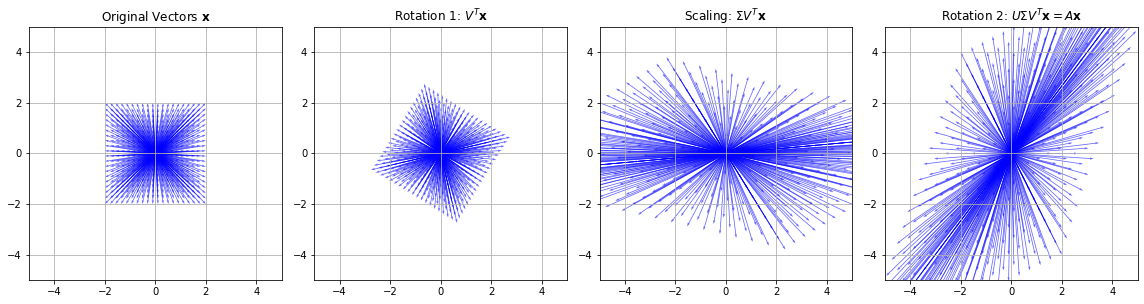

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Create a grid of vectors (2D plane)
x = np.linspace(-2, 2, 20)
y = np.linspace(-2, 2, 20)
X, Y = np.meshgrid(x, y)
vectors = np.stack([X.ravel(), Y.ravel()], axis=0)

# Define a matrix A (non-symmetric, non-orthogonal)
A = np.array([[2, 1],
              [1, 3]])

# Compute SVD: A = U Σ V^T
U, S, VT = np.linalg.svd(A)
Sigma = np.diag(S)

# Decompose transformations
V = VT.T
rotation1 = V
scaling = Sigma
rotation2 = U

# Apply transformations step-by-step
V_vectors = rotation1 @ vectors
S_vectors = scaling @ V_vectors
U_vectors = rotation2 @ S_vectors  # Final result: A @ vectors

# Plotting setup
fig, axs = plt.subplots(1, 4, figsize=(16, 4))

def plot_vectors(ax, vecs, title):
    ax.quiver(np.zeros_like(vecs[0]), np.zeros_like(vecs[1]),
              vecs[0], vecs[1], angles='xy', scale_units='xy', scale=1,
              color='blue', alpha=0.6)
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.grid(True)

# Plot each step
plot_vectors(axs[0], vectors, "Original Vectors $\mathbf{x}$")
plot_vectors(axs[1], V_vectors, "Rotation 1: $V^T\mathbf{x}$")
plot_vectors(axs[2], S_vectors, "Scaling: $\Sigma V^T\mathbf{x}$")
plot_vectors(axs[3], U_vectors, "Rotation 2: $U\Sigma V^T\mathbf{x}=A \mathbf{x}$")

plt.tight_layout()
plt.show()
